In [ ]:
# from libraries import*
import time
import numpy as np
import matplotlib

**Define Lorentz func**

In [3]:

def lorentz(x, gamma, x0, A): #define lorentz fnc for single peak
    return (A*gamma/(np.pi*((x - x0)**2) + gamma**2))

def lorentz_multi(x, gamma, center, split, A): #define fnc for three peaks
    return  lorentz(x, gamma, center + split, A)+ lorentz(x, gamma, center, A) +  lorentz(x, gamma, center - split, A) 

def lorentz_cluster(x, gamma, center_1, split_1, center_2, split_2, A, offset): #define fnc for cluster of six peaks 
    return lorentz_multi(x, gamma, center_1, split_1, A) + lorentz_multi(x, gamma, center_2, split_2, A) + offset

def lorentz_multi_singlet(x, gamma, center_1, center_2, center_3, A, offset): #define fnc for three individual peaks
     return lorentz(x, gamma, center_1, A) + lorentz(x, gamma, center_2, A) + lorentz(x, gamma, center_3, A) + offset

def lorentz_cluster_singlet(x, gamma, center_1,  center_2, center_3, center_4, center_5, center_6, A, offset): #define fnc for cluster of six individual peaks
        return lorentz(x, gamma, center_1, A) + lorentz(x, gamma, center_2, A)  + lorentz(x, gamma, center_3, A) + lorentz(x, gamma, center_4, A) + lorentz(x, gamma, center_5, A) + lorentz(x, gamma, center_6, A) + offset


**Plot variables**

In [12]:
path = "/Users/shiva/Documents/Research/GitHub/Script_project/Data_exp" 
steps = 32768
x_start = 100.06
x_end = -106.0
steps_ppm = (x_end - x_start)/steps
x = np.arange(x_start, x_end, steps_ppm)


**Fitting Routine**

In [13]:
#Input for angle in simulation
file_start = 144                                         #enter the first file number 
file_end = 179                                                      #enter the last file number
skip_file = []

angle_start = 10
angle_end = 360
angle_step = 10

xleft = 12                                                                 # left x limit on plot
xright = -38                                                                 # right x limit on plot

timestamp = time.strftime("%Y%m%d_%H%M%S")                                    #timestamp to seperate files
out_file = f"fit_data_{str(file_start)}_{str(file_end)}_{timestamp}.csv"      #outfile name

#****************provide information of nucleus*********************************
s = 3/2         #spin of nuclei
clusters = 2    # magnetically different nuclei in unit cell
peaks = int(2*s) #peaks in one cluster

#******************************-8HQ Y rotation****************************
#****************provide initial values*****************************************
initializer_list = [ 
    # {'gamma': 1, 'center_1': 0.7, 'split_1': 3, 'center_2': -5, 'split_2': 3, 'A': 1, 'offset': 0.}, #141
    # {'gamma': 1, 'center_1': -3, 'split_1': 1, 'center_2': -5, 'split_2' : 3, 'A': 1, 'offset': 0.}, # 142                                                                   
    # {'gamma': 1, 'center_1': -0.5, 'split_1': 5, 'center_2': -5, 'split_2' : 5, 'A': 1, 'offset': 0.}, #143
    {'gamma': 1, 'center_1': -0.6, 'split_1': 1, 'center_2': -4.4, 'split_2' : 1, 'A': 1, 'offset': 0.}, #144
    {'gamma': 1, 'center_1': -4, 'split_1': 1, 'center_2': -6, 'split_2': 1, 'A': 1, 'offset': 0.}, #145
    {'gamma': 1, 'center_1': -4, 'split_1': 1, 'center_2': -7, 'split_2' : 1, 'A': 1, 'offset': 0.}, #146
    {'gamma': 1, 'center_1': -6, 'split_1': 1, 'center_2': -9, 'split_2' : 1, 'A': 1, 'offset': 0.}, #147
    {'gamma': 1, 'center_1': -9, 'split_1': 3, 'center_2': -11, 'split_2' : 3, 'A': 1, 'offset': 0.}, #148
    {'gamma': 1, 'center_1': -14, 'split_1': 1, 'center_2': -14, 'split_2' : 1, 'A': 1, 'offset': 0.}, #149
    {'gamma': 1, 'center_1': -20, 'split_1': 1, 'center_2': -20, 'split_2' : 1, 'A': 1, 'offset': 0.}, #150
    {'gamma': 1, 'center_1': -24, 'split_1': 1, 'center_2': -24, 'split_2' : 1, 'A': 1, 'offset': 0.}, #151
    {'gamma': 1, 'center_1': -29, 'split_1': 1, 'center_2': -29, 'split_2' : 1, 'A': 1, 'offset': 0.}, #152
    {'gamma': 1, 'center_1': -30, 'split_1': 1, 'center_2': -30, 'split_2' : 1, 'A': 1, 'offset': 0.}, #153
    {'gamma': 1, 'center_1': -27, 'split_1': 1, 'center_2': -31, 'split_2' : 1, 'A': 1, 'offset': 0.}, #154
    {'gamma': 1, 'center_1': -22, 'split_1': 1, 'center_2': -27, 'split_2' : 1, 'A': 1, 'offset': 0.}, #155
    {'gamma': 1, 'center_1': -16, 'split_1': 5, 'center_2': -21, 'split_2' : 5, 'A': 1, 'offset': 0.}, #156
    {'gamma': 1, 'center_1': -9, 'split_1': 1, 'center_2': -14, 'split_2' : 1, 'A': 1, 'offset': 0.}, #157
    {'gamma': 1, 'center_1': -7, 'split_1': 5, 'center_2': -7, 'split_2' : 5, 'A': 2, 'offset': 0.}, #158
    {'gamma': 1, 'center_1': -3, 'split_1': 5, 'center_2': -4, 'split_2' : 5, 'A': 1, 'offset': 0.}, #159
    {'gamma': 1, 'center_1': -3, 'split_1': 1, 'center_2': -6, 'split_2' : 1, 'A': 1, 'offset': 0.}, #160
    {'gamma': 1, 'center_1': -3, 'split_1': 3, 'center_2': -8, 'split_2' : 3, 'A': 2, 'offset': 0.}, #161
    {'gamma': 1, 'center_1': -4, 'split_1': 3, 'center_2': -4, 'split_2' : 3, 'A': 2, 'offset': 0.}, #162                                                                   
    {'gamma': 1, 'center_1': -5, 'split_1': 1, 'center_2': 0.7, 'split_2': 1, 'A': 1, 'offset': 0.}, #163
    {'gamma': 1, 'center_1': -8, 'split_1': 1, 'center_2': -3, 'split_2' : 3, 'A': 1, 'offset': 0.}, # 164
    {'gamma': 1, 'center_1': -9, 'split_1': 3, 'center_2': -5, 'split_2' : 3, 'A': 1, 'offset': 0.}, #165
    {'gamma': 1, 'center_1': -11, 'split_1': 1, 'center_2': -9, 'split_2' : 1, 'A': 1, 'offset': 0.}, #166
    {'gamma': 1, 'center_1': -14, 'split_1': 3, 'center_2': -13.8, 'split_2': 3, 'A': 1, 'offset': 0.}, #167
    {'gamma': 1, 'center_1': -20, 'split_1': 3, 'center_2': -19, 'split_2' : 3, 'A': 1, 'offset': 0.}, #168
    {'gamma': 1, 'center_1': -27, 'split_1': 3, 'center_2': -22, 'split_2' : 3, 'A': 1, 'offset': 0.}, #169
    {'gamma': 1, 'center_1': -29, 'split_1': 3, 'center_2': -28, 'split_2' : 3, 'A': 1, 'offset': 0.}, #170
    {'gamma': 1, 'center_1': -29, 'split_1': 1, 'center_2': -31, 'split_2' : 1, 'A': 1, 'offset': 0.}, #171
    {'gamma': 1, 'center_1': -26, 'split_1': 1, 'center_2': -31, 'split_2' : 1, 'A': 1, 'offset': 0.}, #172
    {'gamma': 1, 'center_1': -21, 'split_1': 1.5, 'center_2': -27.5, 'split_2' : 1.5, 'A': 1, 'offset': 0.}, #173
    {'gamma': 1, 'center_1': -14, 'split_1': 2, 'center_2': -21, 'split_2' : 2, 'A': 1, 'offset': 0.}, #174
    {'gamma': 1, 'center_1': -8, 'split_1': 5, 'center_2': -14, 'split_2' : 5, 'A': 1, 'offset': 0.}, #175
    {'gamma': 1, 'center_1': -6, 'split_1': 5, 'center_2': -7, 'split_2' : 5, 'A': 1, 'offset': 0.}, #176
    {'gamma': 1, 'center_1': -4, 'split_1': 3, 'center_2': -8, 'split_2' : 3, 'A': 2, 'offset': 0.}, #177
    {'gamma': 1, 'center_1': 0, 'split_1': 3, 'center_2': -5, 'split_2' : 3, 'A': 2, 'offset': 0.},#178
    {'gamma': 1, 'center_1': -0.5, 'split_1': 5, 'center_2': -5, 'split_2' : 5, 'A': 2, 'offset': 0.}, #179
    ]


# Initialize the CSV file
with open(path + out_file, 'w', newline='') as csvfile:
    fieldnames = ['file', 'center_1', 'center_2', 'center_3', 'center_4', 'center_5', 'center_6', 'Comment']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()   
    
    encountered_angles = {}  # Dictionary to track encountered angles

    angle_counter = 1       # Initialize angle counter

    for numb, initial_values in zip(range(file_start, file_end+1), initializer_list):
        if numb in skip_file:
            continue 
        # Calculate angle based on file number
        angle = f"$\\theta$  = {angle_counter * angle_step}"

        # Check if angle has been encountered before
        if angle in encountered_angles:
            # Skip this file if the angle has been encountered before
            continue
        else:
            # Add the angle to the dictionary
            encountered_angles[angle] = numb
            angle_counter += 1  # Increment angle counter
        yData = np.loadtxt(path+"SW_Shiva"+str(numb)+".txt", unpack=True )                          # read in  
        yData = yData / max(yData)                                                                  # normalize
        yData = yData - min(yData)                                                                  # remove any vertical offset
        least_squares = LeastSquares(x, yData, 0.1, lorentz_cluster)
        m = Minuit(least_squares, **initial_values).migrad()
        # corr_mat = (m.covariance.correlation())
        # print(corr_mat)
        # print(m.migrad())
        residual = yData - lorentz_cluster(x, *m.values)                                            # finding residual
        # if np.any(np.abs(residual) > 0.2):                                                          # alert when residual is too large and record in excel file
        #     print("\033[91mCheck!!!\033[0m")

        m_fit_info = [f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m.fval:.1f} / {m.ndof:.0f} = {m.fmin.reduced_chi2:.1f}"]    
        

     #*****************Plotting************************************************
        triplet_1 = lorentz_multi(x, m.values['gamma'], m.values['center_1'], m.values['split_1'], m.values['A']) + m.values['offset']
        triplet_2 = lorentz_multi(x, m.values['gamma'], m.values['center_2'], m.values['split_2'], m.values['A']) + m.values['offset'] 
        # plt.figure(figsize=(20,3))
        # plt.plot(x, yData, '--', label="exp")
        # plt.plot(x, lorentz_cluster(x, *m.values), label="fit", color = 'red')  
        # plt.plot(x,triplet_1, label = "triplet_set1",color = "orange") 
        # plt.plot(x,triplet_2, label = "triplet_set2",color = "green")
        # plt.xticks(np.arange(min(x), max(x)+1, 2.0)) 
        # plt.title("File:"+str(numb) + " ;" + angle + ' constrained fit')
        # plt.plot(x, residual, color = 'grey', label = "residual")
        # plt.axhline(y = 0, xmin= x_start, xmax= x_end, color = 'black') #zero reference line
        # plt.xlim([xleft, xright])                                              #choose 
        # plt.grid()
        # plt.legend(title="\n".join(m_fit_info), loc='upper left')
        # plt.show()

        # *****************Printing fit result*************************************
        # print(f"Results for data file SW_Shiva{numb}.txt:")
        # for key, value in zip(m.parameters, m.values):
        #     print(f"{key} = {value}")
       

        # # *****************Printing peak positions********************************
        # cluster_1_center = m.values['center_1']
        # cluster_2_center = m.values['center_2']
        # Cluster_1_sep = m.values['split_1']                 #separation of peaks in cluster 1
        # Cluster_2_sep = m.values['split_2']                 #separation of peaks in cluster 2
        # peak_width = m.values['gamma']
        # peak_height = m.values['A']

        # #*************************Writing data to output file***********************
        # parameter = [(cluster_1_center, Cluster_1_sep),(cluster_2_center, Cluster_2_sep)]
        # peak_arrays = [[] for _ in range(len(parameter))]

        # for id, (a,i) in enumerate(parameter):
        #     peak_array = []
        #     for j in range(-peaks+2, peaks-1):
        #         key = f"result{id + 1}_{j}"
        #         result = a - j * i
        #         peak_array.append(result)
        #     peak_arrays[id] = peak_array
        #     print(f"Cluster {id + 1}", peak_array)

        #Program to fit individual peaks using initial values from program using center and split parameters

        least_squares_singlet = LeastSquares(x, yData, 0.1, lorentz_cluster_singlet)
        m_singlet = Minuit(least_squares_singlet, gamma = m.values['gamma'], center_1= (m.values['center_1'] -  m.values['split_1']), center_2 =  m.values['center_1'], 
                        center_3 = (m.values['center_1'] + m.values['split_1']), center_4  =  (m.values['center_2'] - m.values['split_2']),center_5 = m.values['center_2'],
                            center_6 =  (m.values['center_2'] + m.values['split_2']), A =  m.values['A'], offset =  m.values['offset']).migrad()

        residual = yData - lorentz_cluster_singlet(x, *m_singlet.values)                                         # finding residual
        row_dict = {'file': numb,'Comment': ''}                                                                  # Define row_dict inside the loop
        # if np.any(np.abs(residual) > 0.1):                                                                       # alert when residual is too large and record in excel file
        #     row_dict['Comment'] = 'Check!!!'
        #     print("\033[91mCheck!!!\033[0m")
        m_singlet_fit_info = [f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_singlet.fval:.1f} / {m_singlet.ndof:.0f} = {m_singlet.fmin.reduced_chi2:.1f}"] 
        #*****************Plotting************************************************
        
        peak_1 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_1'],m_singlet.values['A']) + m_singlet.values['offset'] 
        peak_2 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_2'],m_singlet.values['A']) + m_singlet.values['offset']
        peak_3 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_3'],m_singlet.values['A']) + m_singlet.values['offset']
        peak_4 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_4'],m_singlet.values['A']) + m_singlet.values['offset'] 
        peak_5 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_5'],m_singlet.values['A']) + m_singlet.values['offset']
        peak_6 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_6'],m_singlet.values['A']) + m_singlet.values['offset']          
        plt.figure(figsize=(15,5), dpi = 150)

        plt.plot(x, yData, '--', label="data")
        plt.plot(x, lorentz_cluster_singlet(x, *m_singlet.values), label="fit", color = 'olive')  
        plt.plot(x,peak_1 )
        plt.plot(x, peak_2)
        plt.plot(x, peak_3)
        plt.plot(x, peak_4)
        plt.plot(x, peak_5)
        plt.plot(x, peak_6)
        plt.xticks(np.arange(min(x), max(x)+1, 2.0)) 
        plt.title("File:"+str(numb) + " ; " + angle+ ' Six Individual Lorentzian Function Deconvolution', fontsize =18)
        plt.plot(x, residual, color = 'grey', label = "residual")
        plt.axhline(y = 0, xmin= x_start, xmax= x_end, color = 'black') #zero reference line
        plt.xlim([xleft, xright]) 
        # plt.grid()
        # plt.legend(title="\n".join(m_singlet_fit_info), loc='upper left')
        plt.legend( loc='upper left', fontsize = 16)
        plt.xlabel("Chemical Shift / ppm", fontsize=16)
        plt.ylabel("Normalized Amplitude", fontsize=16)
        plt.show()
    #Printing results***********************************************
        print(f"Results for data file SW_Shiva{numb}.txt:")

        for key, value in zip(m_singlet.parameters, m_singlet.values):
            print(f"{key} = {value}")
        

    #******************Saving results in CSV file*********************************************
            
    # Extract the values of center parameters from m_singlet.values
        center_values = [m_singlet.values[f'center_{i}'] for i in range(1, 7)]



    # Construct the row dictionary
        row_dict = {
            'file': numb,
            'center_1': center_values[0],
            'center_2': center_values[1],
            'center_3': center_values[2],
            'center_4': center_values[3],
            'center_5': center_values[4],
            'center_6': center_values[5],
            'Comment': row_dict['Comment']  # Include the 'Comment' key as well
        }
        if np.any(np.abs(residual) > 0.1):
            row_dict['Comment'] = 'Check!!!'
        # Write row to CSV file
        writer.writerow(row_dict)

NameError: name 'csv' is not defined

In [5]:
A_coeff = []; B_coeff = []; C_coeff = []; D_coeff = []; E_coeff = []
for i in range(len(m)):  # Or directly 'for i in range(len(m))' if the length isn't fixed
    A_coeff_val, B_coeff_val, C_coeff_val, D_coeff_val, E_coeff_val = m[i].values[:5]
    A_coeff.append(A_coeff_val); 
    B_coeff.append(B_coeff_val); 
    C_coeff.append(C_coeff_val); 
    D_coeff.append(D_coeff_val); 
    E_coeff.append(E_coeff_val)

TypeError: object of type 'Minuit' has no len()

In [9]:
print(m.parameters)

('gamma', 'center_1', 'split_1', 'center_2', 'split_2', 'A', 'offset')


**Stacked Plot**

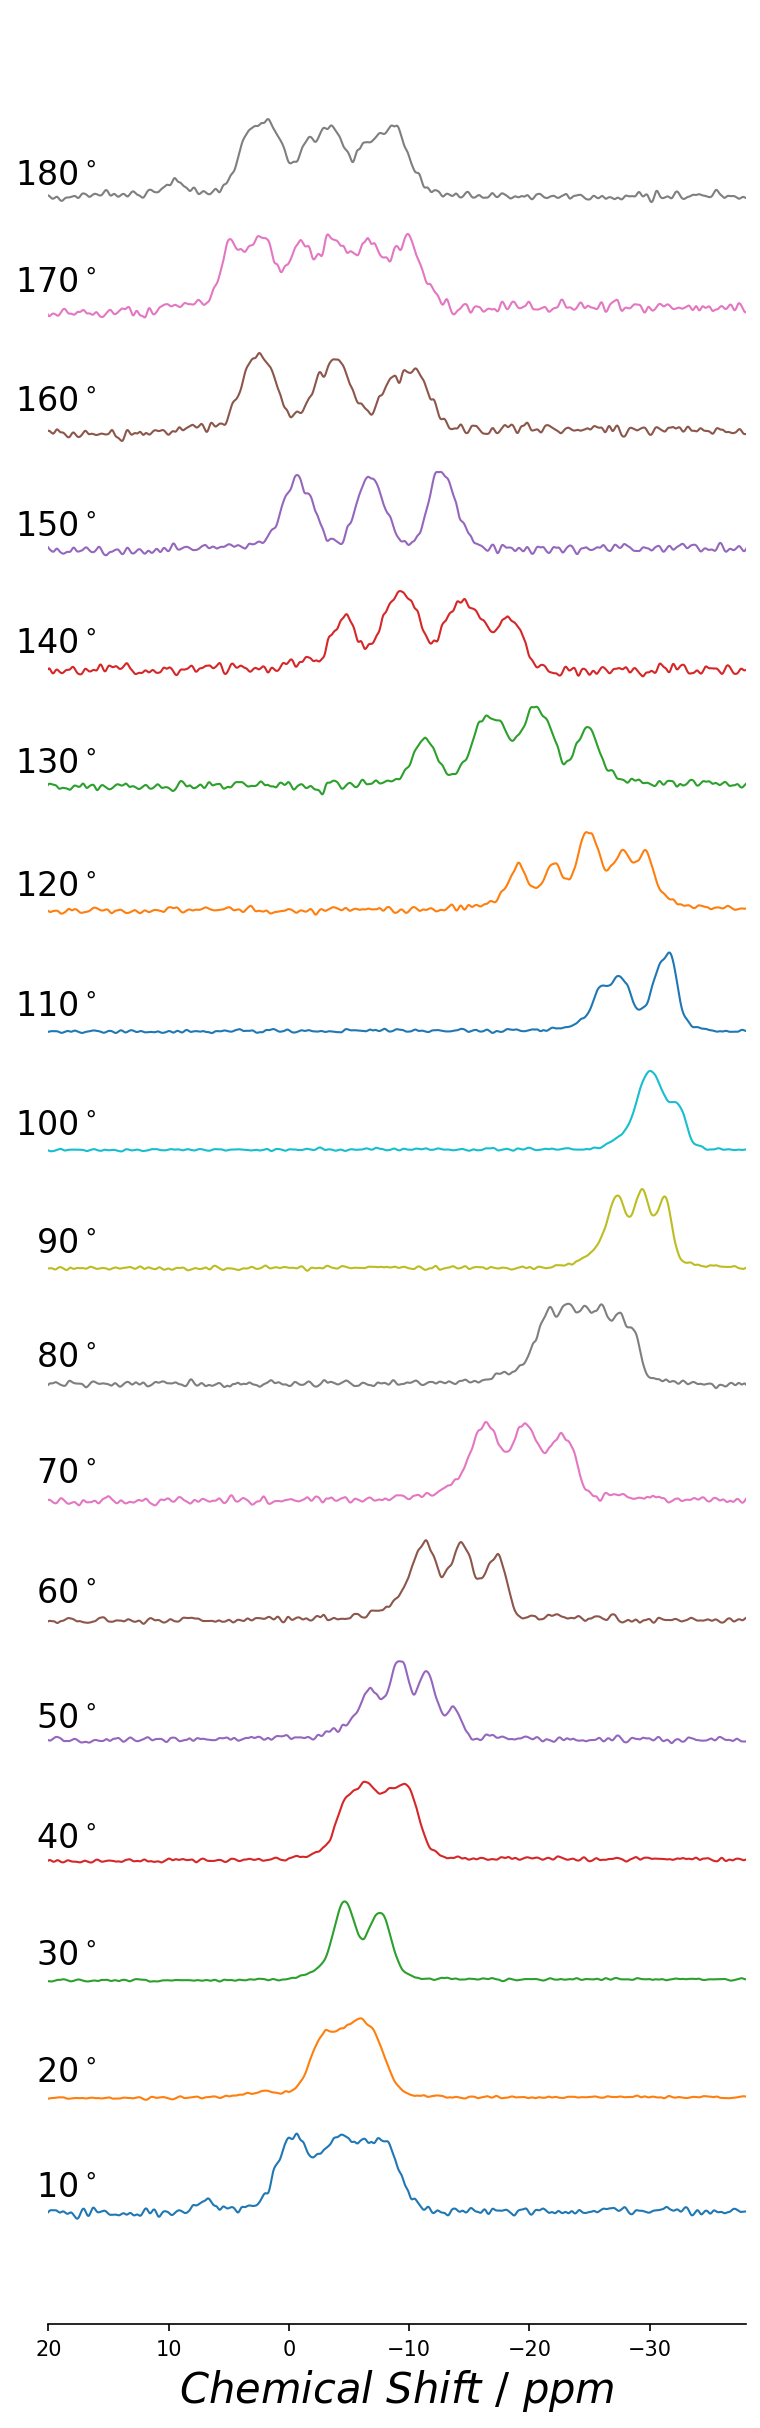

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Provide input to read data *********************************************
path = "//Users/shiva/Documents/Research/GitHub/Script_project/Data_exp/" 
file_start = 144                                      # enter the first file number 
file_end = 161                                          # enter the last file number
skip_file = [138, 139, 140, 141, 142, 143]                                          # skip this file number
angle_start = 10
angle_end = 360
angle_step = 10

# Initialize an empty list to store data arrays
data_list = []
for numb in range(file_start, file_end+1):
    if numb in skip_file:
        continue  # Skip the specified file
    yData = np.loadtxt(path + f"SW_Shiva{numb}.txt", unpack=True)  # read in  
    yData = yData / max(yData)  # normalize
    yData = yData - min(yData)  # remove any vertical offset
    data_list.append(yData)

# Adjust the x-axis ******************************************************
steps = 32768
x_start = 100.06
x_end = -106.0
steps_ppm = (x_end - x_start) / steps
x = np.arange(x_start, x_end, steps_ppm)  

# Plot the data ********************************
fig, ax = plt.subplots(figsize=(6, 20), dpi = 150)  # Create the figure and axes
labels = [rf"${i}^\circ$" for i in range(angle_start, angle_end+angle_step, angle_step)]

# Plot line plots ********************************
for i, (data, label) in enumerate(zip(data_list, labels)):
    offset = i * 1.5                                                                                   # You can adjust the offset value
    ax.plot(x, data + offset, linewidth=1)
    
    ax.text(16, (offset + 0.3 ) + data[0], label, color='black', va='center', ha='right', fontsize=16) #Adjust the position of label by changing numeric value
    # plt.text(-37, (offset + 0.3 ) + data[0],"File:"+str(number), ha = 'right')


# Adjust plot aesthetics
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xlim([20, -38])  # Set x-axis limits
ax.set_xlabel(r'$Chemical\ Shift\ /\ ppm$', fontsize=20)

# Hide the top spine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
# plt.title('Stack Plot of Data from Files')
# plt.legend(loc='upper left')

# Save the plot to a specific folder
# Adjust layout
# plt.tight_layout()

plt.show()


fig.savefig('/Users/shiva/Documents/Research/GitHub/Script_project/NMR_analysis/plots_experiment/Y_stacked_LHQ.png', dpi = 50 ,bbox_inches='tight')

